In [9]:
# Uncomment this in a fresh notebook environment.
#%pip install -r ../requirements.txt

In [10]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

In [11]:
from simulation_generator import SimulationGenerator
from traffic_env import SumoTrafficEnv
from statistics import mean
import matplotlib.pyplot as plt

## Generate the SUMO simulation files

`SimulationGenerator` creates the network, trips, routes, and SUMO config file.

In [12]:
generator = SimulationGenerator(
    output_dir=PROJECT_ROOT / "outputs",
    network_type="grid",
    grid_number=3,
    lane_number=1,
    guess_tls=True,
    trip_begin=0,
    trip_end=1000,
    trip_period=2,
    seed=42,
)

paths = generator.generate_all()

## Create the PettingZoo environment

`SumoTrafficEnv` starts SUMO through TraCI, discovers SUMO traffic light IDs, and treats each traffic light as one PettingZoo agent.

For the first version, each agent observes queue counts on its controlled lanes. Observations are normalized and padded to a fixed length so reinforcement learning libraries can consume them.

In [13]:
env = SumoTrafficEnv(
    config_file=paths.config_file,
    max_steps=100,
    seconds_per_action=5,
    max_lanes_per_tls=16,
    seed=42,
    render_mode=None,  # use "human" to run sumo-gui for visual debugging
)

observations, infos = env.reset(seed=42)
print("Agents:", env.agents)
print("Number of agents:", len(env.agents))
print("First observation shape:", next(iter(observations.values())).shape if observations else None)
env.close()

Agents: []
Number of agents: 0
First observation shape: None


## Smoke test with random actions

Before training, always check that random actions can run through the environment. This is much easier to debug than a failed training run.

The reward is currently the negative total queue length around each traffic light, so less negative is better.

In [14]:
env = SumoTrafficEnv(
    config_file=paths.config_file,
    max_steps=100,
    seconds_per_action=5,
    max_lanes_per_tls=16,
    seed=42,
)

observations, infos = env.reset(seed=42)
total_rewards = {agent: 0.0 for agent in env.agents}

for step in range(100):
    actions = {agent: env.action_space(agent).sample() for agent in env.agents}
    observations, rewards, terminations, truncations, infos = env.step(actions)

    for agent, reward in rewards.items():
        total_rewards[agent] += reward

    if not env.agents:
        break

env.close()

print("Completed random-action smoke test.")
print("Steps run:", step + 1)
print("Example total rewards:")
for agent, reward in list(total_rewards.items())[:5]:
    print(f"  {agent}: {reward:.1f}")

Completed random-action smoke test.
Steps run: 1
Example total rewards:


## PPO training

In [15]:
def make_env(seed=42, max_steps=200):
    """Create a fresh environment for one experiment run."""
    return SumoTrafficEnv(
        config_file=paths.config_file,
        max_steps=max_steps,
        seconds_per_action=5,
        max_lanes_per_tls=16,
        seed=seed,
    )


def random_controller(env, observations, step):
    """Choose a random valid action for each traffic light."""
    return {
        agent: env.action_space(agent).sample()
        for agent in env.agents
    }


def fixed_cycle_controller(env, observations, step, phase_hold_steps=4):
    """Cycle each traffic light through its available green phases."""
    actions = {}

    for agent in env.agents:
        number_of_actions = env.action_space(agent).n
        actions[agent] = (step // phase_hold_steps) % number_of_actions

    return actions


def _green_lanes_for_action(env, agent, action):
    """
    Return the incoming lanes that would receive green for one action.

    This uses SUMO's traffic-light program to map our PettingZoo action number
    back to a real SUMO phase, then checks which controlled links are green.
    """
    traci = env._import_traci()
    green_phases = env._tls_to_green_phases.get(agent, [0])
    phase_index = green_phases[int(action) % len(green_phases)]

    program = traci.trafficlight.getCompleteRedYellowGreenDefinition(agent)[0]
    phase_state = program.phases[phase_index].state
    controlled_links = traci.trafficlight.getControlledLinks(agent)

    green_lanes = set()

    for signal_index, signal_state in enumerate(phase_state):
        if signal_state.lower() != "g":
            continue

        if signal_index >= len(controlled_links):
            continue

        for connection in controlled_links[signal_index]:
            if connection:
                incoming_lane = connection[0]
                green_lanes.add(incoming_lane)

    return green_lanes


def queue_based_controller(env, observations, step):
    """Choose the phase with the largest currently queued demand."""
    traci = env._import_traci()
    actions = {}

    for agent in env.agents:
        number_of_actions = env.action_space(agent).n
        best_action = 0
        best_queue = -1

        for action in range(number_of_actions):
            green_lanes = _green_lanes_for_action(env, agent, action)
            queue_for_action = sum(
                traci.lane.getLastStepHaltingNumber(lane_id)
                for lane_id in green_lanes
            )

            if queue_for_action > best_queue:
                best_queue = queue_for_action
                best_action = action

        actions[agent] = best_action

    return actions


def run_episode(controller, seed=42, max_steps=200):
    """Run one full episode and return summary metrics."""
    env = make_env(seed=seed, max_steps=max_steps)
    observations, infos = env.reset(seed=seed)

    total_rewards = {agent: 0.0 for agent in env.agents}
    mean_reward_by_step = []

    try:
        for step in range(max_steps):
            actions = controller(env, observations, step)
            observations, rewards, terminations, truncations, infos = env.step(actions)

            if rewards:
                mean_reward_by_step.append(mean(rewards.values()))

            for agent, reward in rewards.items():
                total_rewards[agent] += reward

            if not env.agents:
                break
    finally:
        env.close()

    total_network_reward = sum(total_rewards.values())
    average_step_reward = mean(mean_reward_by_step) if mean_reward_by_step else 0.0

    return {
        "steps": step + 1,
        "total_network_reward": total_network_reward,
        "average_step_reward": average_step_reward,
        "per_agent_rewards": total_rewards,
    }

## Model evaluation

The evaluation environment should use the same observation setup as training.

Running random controller...


Running fixed_cycle controller...
Running queue_based controller...

Controller comparison
------------------------------------------------------------------------
Controller          Steps       Total reward    Avg step reward
------------------------------------------------------------------------
random                  1                0.0               0.00
fixed_cycle             1                0.0               0.00
queue_based             1                0.0               0.00


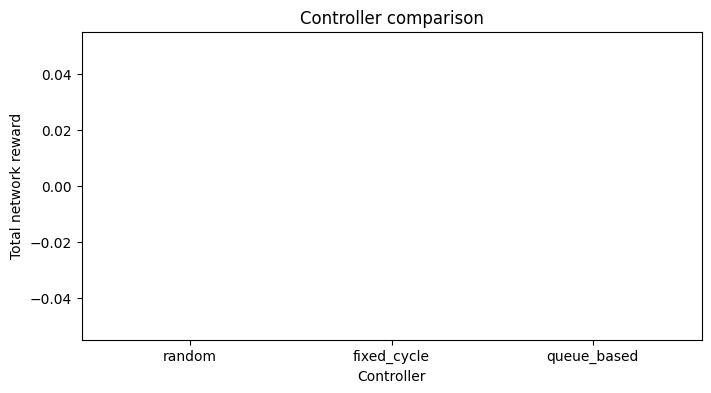

In [16]:
controllers = {
    "random": random_controller,
    "fixed_cycle": fixed_cycle_controller,
    "queue_based": queue_based_controller,
}

results = {}

for name, controller in controllers.items():
    print(f"Running {name} controller...")
    results[name] = run_episode(controller, seed=42, max_steps=200)

print("\nController comparison")
print("-" * 72)
print(f"{'Controller':<16} {'Steps':>8} {'Total reward':>18} {'Avg step reward':>18}")
print("-" * 72)

for name, result in results.items():
    print(
        f"{name:<16} "
        f"{result['steps']:>8} "
        f"{result['total_network_reward']:>18.1f} "
        f"{result['average_step_reward']:>18.2f}"
    )

names = list(results.keys())
scores = [results[name]["total_network_reward"] for name in names]

plt.figure(figsize=(8, 4))
plt.bar(names, scores)
plt.title("Controller comparison")
plt.xlabel("Controller")
plt.ylabel("Total network reward")
plt.show()